In [1]:
import pandas as pd

df = pd.read_csv("data/diabetes_raw.csv")

print(df.shape)
df.head()

(253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


## 1. Data Validation 

In [2]:
#Check data types and missing values

print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())


HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

Missing values per column:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcar

In [3]:
print("Total missing values:", df.isnull().sum().sum()) #total missing values across the df

print("Duplicate rows:",df.duplicated().sum()) #check for duplicate rows

Total missing values: 0
Duplicate rows: 24206


In [4]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (229474, 22)


In [5]:
print(df.describe().T) #Value ranges - Flag anything suspicious

                         count       mean       std   min   25%   50%   75%  \
HighBP                229474.0   0.454343  0.497912   0.0   0.0   0.0   1.0   
HighChol              229474.0   0.441640  0.496584   0.0   0.0   0.0   1.0   
CholCheck             229474.0   0.959481  0.197173   0.0   1.0   1.0   1.0   
BMI                   229474.0  28.687507  6.789204  12.0  24.0  27.0  32.0   
Smoker                229474.0   0.465800  0.498830   0.0   0.0   0.0   1.0   
Stroke                229474.0   0.044816  0.206899   0.0   0.0   0.0   0.0   
HeartDiseaseorAttack  229474.0   0.103336  0.304398   0.0   0.0   0.0   0.0   
PhysActivity          229474.0   0.733042  0.442371   0.0   0.0   1.0   1.0   
Fruits                229474.0   0.612675  0.487140   0.0   0.0   1.0   1.0   
Veggies               229474.0   0.794587  0.404004   0.0   1.0   1.0   1.0   
HvyAlcoholConsump     229474.0   0.060791  0.238947   0.0   0.0   0.0   0.0   
AnyHealthcare         229474.0   0.946011  0.225996 

In [7]:
print(df[['BMI', 'GenHlth', 'MentHlth', 'PhysHlth']].max())

BMI         98
GenHlth      5
MentHlth    30
PhysHlth    30
dtype: int64


In [6]:
print(df['Diabetes_binary'].value_counts())
print(df['Diabetes_binary'].value_counts(normalize=True))

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64
Diabetes_binary
0    0.847055
1    0.152945
Name: proportion, dtype: float64


**Validation summary:** 229,474 rows after removing 24,206 exact duplicates (24,206 removed to prevent train/test leakage, not necessarily erroneous — many features are binary/low-cardinality so coincidental matches are expected). 0 missing values. All value ranges match the BRFSS codebook (e.g. Age 1-13, Education 1-6, Income 1-8, BMI 12-98). Target is imbalanced: 84.7% no diabetes, 15.3% diabetes/prediabetes.


## 2. Exploratory Data Analysis

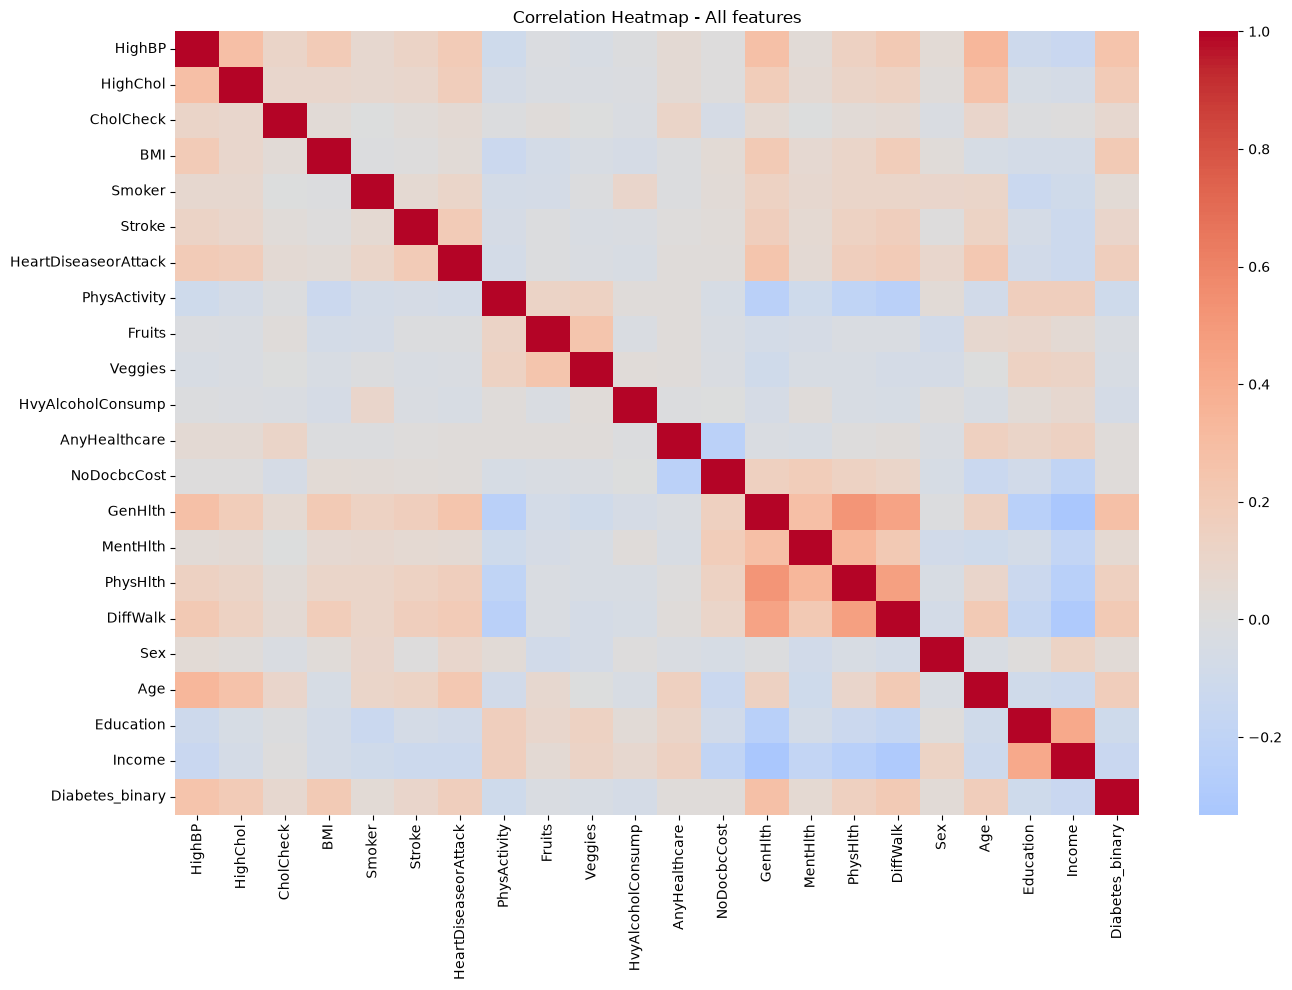

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm',center=0, annot=False)
plt.title('Correlation Heatmap - All features')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

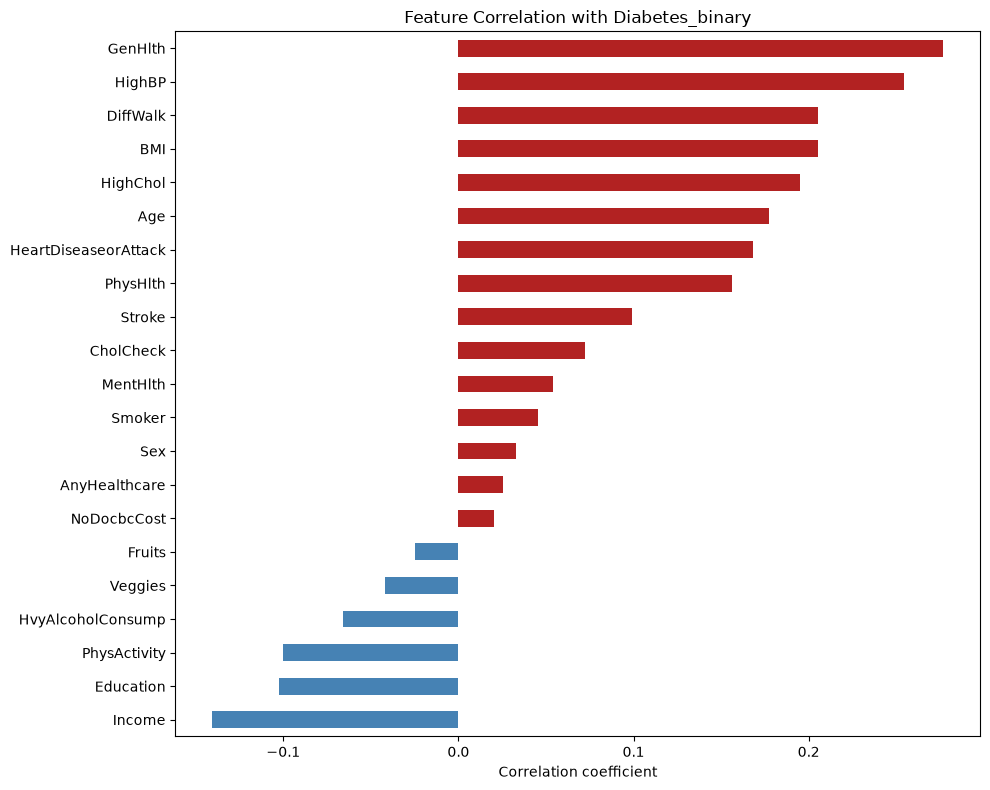

In [9]:
# correlation of every feature with the target, sorted
target_corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values()

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=['steelblue' if x < 0 else 'firebrick' for x in target_corr])
plt.title('Feature Correlation with Diabetes_binary')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('outputs/target_correlation.png', dpi=150)
plt.show()

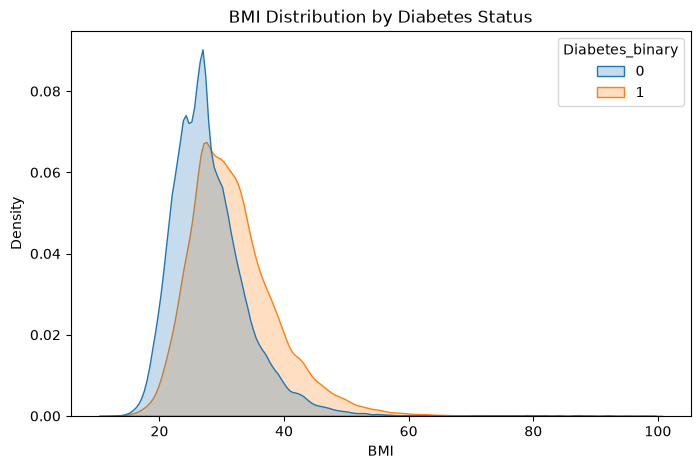

In [10]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='BMI', hue='Diabetes_binary', fill=True, common_norm=False)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('BMI')
plt.savefig('outputs/bmi_distribution.png', dpi=150)
plt.show()

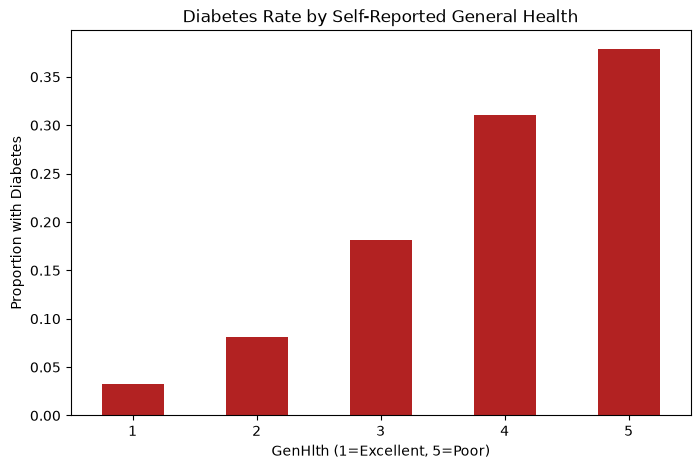

In [11]:
diabetes_rate_by_health = df.groupby('GenHlth')['Diabetes_binary'].mean()

plt.figure(figsize=(8, 5))
diabetes_rate_by_health.plot(kind='bar', color='firebrick')
plt.title('Diabetes Rate by Self-Reported General Health')
plt.xlabel('GenHlth (1=Excellent, 5=Poor)')
plt.ylabel('Proportion with Diabetes')
plt.xticks(rotation=0)
plt.savefig('outputs/genhlth_diabetes_rate.png', dpi=150)
plt.show()

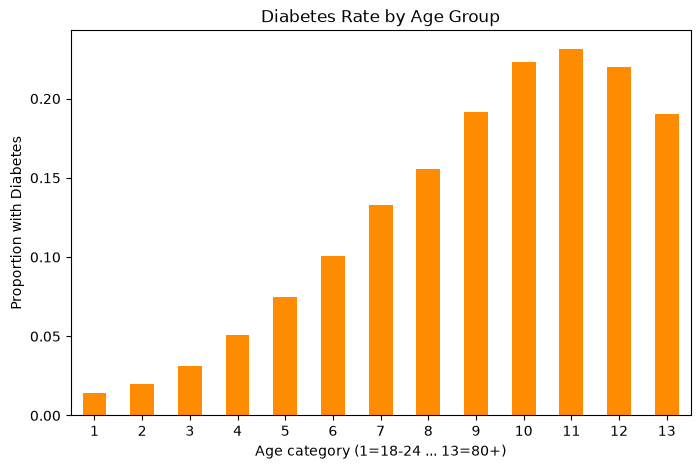

In [12]:
diabetes_rate_by_age = df.groupby('Age')['Diabetes_binary'].mean()

plt.figure(figsize=(8, 5))
diabetes_rate_by_age.plot(kind='bar', color='darkorange')
plt.title('Diabetes Rate by Age Group')
plt.xlabel('Age category (1=18-24 ... 13=80+)')
plt.ylabel('Proportion with Diabetes')
plt.xticks(rotation=0)
plt.savefig('outputs/age_diabetes_rate.png', dpi=150)
plt.show()

**EDA summary:** No single feature strongly predicts diabetes alone (max correlation ~0.27, GenHlth). Self-reported general health shows the cleanest signal — diabetes rate rises monotonically from 3% (excellent health) to 38% (poor health). Diabetes rate also climbs steadily with age through the mid-60s/70s, then slightly declines in the oldest brackets (70+) — possibly survivorship bias. BMI shows a real but overlapping shift toward higher values in diabetic patients. These patterns suggest a model needs to combine multiple weak-to-moderate signals rather than rely on one dominant feature — supporting the choice of a tree-based model that captures feature interactions.

## 3. Feature Engineering

In [13]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # underweight
    elif bmi < 25:
        return 1  # normal
    elif bmi < 30:
        return 2  # overweight
    elif bmi < 35:
        return 3  # obese
    else:
        return 4  # severely obese

df['BMI_category'] = df['BMI'].apply(bmi_category)
df[['BMI', 'BMI_category']].head()

,BMI,BMI_category
0,40,4
1,25,2
2,28,2
3,27,2
4,24,1


In [14]:
df['TotalUnhealthyDays'] = df['MentHlth'] + df['PhysHlth']
df['TotalUnhealthyDays'] = df['TotalUnhealthyDays'].clip(upper=30)

df[['MentHlth', 'PhysHlth', 'TotalUnhealthyDays']].head()

,MentHlth,PhysHlth,TotalUnhealthyDays
0,18,15,30
1,0,0,0
2,30,30,30
3,0,0,0
4,3,0,3


In [15]:
df['CardioRiskCount'] = df['HighBP'] + df['HighChol'] + df['HeartDiseaseorAttack'] + df['Stroke']

df[['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'Stroke', 'CardioRiskCount']].head()

,HighBP,HighChol,HeartDiseaseorAttack,Stroke,CardioRiskCount
0,1,1,0,0,2
1,0,0,0,0,0
2,1,1,0,0,2
3,1,0,0,0,1
4,1,1,0,0,2


## 4. Modeling

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train diabetes rate:", y_train.mean())
print("Test diabetes rate:", y_test.mean())

Train shape: (183579, 24)
Test shape: (45895, 24)
Train diabetes rate: 0.15294777725121064
Test diabetes rate: 0.15293604967861424


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# scale features - logistic regression is sensitive to different scales (e.g. BMI ranges 12-98, Sex is 0/1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Baseline logistic regression trained.")

Baseline logistic regression trained.


In [18]:
from sklearn.ensemble import RandomForestClassifier

# random forest doesn't need scaled features - it splits on raw values, not distances
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Random forest trained.")

Random forest trained.


In [19]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# get predictions and probabilities from both models
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, log_reg_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_proba))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     38876
           1       0.32      0.76      0.45      7019

    accuracy                           0.72     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.85      0.72      0.75     45895

ROC-AUC: 0.8118888395337975

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     38876
           1       0.39      0.44      0.41      7019

    accuracy                           0.81     45895
   macro avg       0.64      0.66      0.65     45895
weighted avg       0.82      0.81      0.81     45895

ROC-AUC: 0.7811327956553655


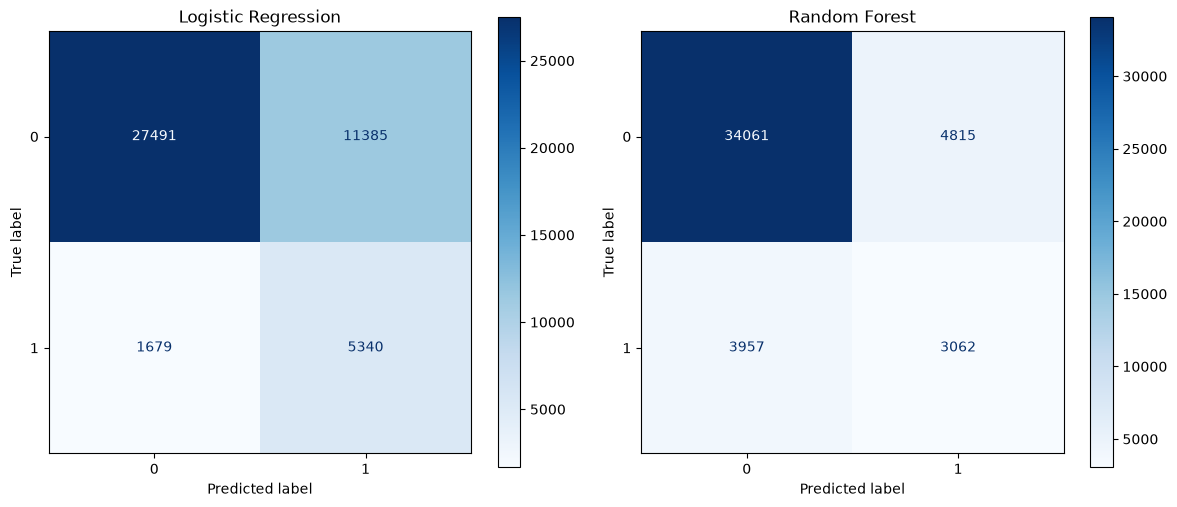

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, log_reg_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150)
plt.show()

In [21]:
custom_threshold = 0.3
rf_pred_adjusted = (rf_proba >= custom_threshold).astype(int)

print(f"=== Random Forest at threshold={custom_threshold} (default is 0.5) ===")
print(classification_report(y_test, rf_pred_adjusted))

=== Random Forest at threshold=0.3 (default is 0.5) ===
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     38876
           1       0.30      0.73      0.43      7019

    accuracy                           0.70     45895
   macro avg       0.62      0.71      0.61     45895
weighted avg       0.84      0.70      0.74     45895



**Modeling summary:** Logistic regression (ROC-AUC 0.81) and Random Forest (ROC-AUC 0.78) perform similarly at ranking risk. At default thresholds, logistic regression's balanced class weighting produced much better recall (0.76 vs 0.44) than Random Forest's, but adjusting Random Forest's decision threshold from 0.5 to 0.3 closed most of that gap (recall 0.73, comparable precision), at the cost of overall accuracy dropping from 0.81 to 0.70. This confirms accuracy alone is misleading for an imbalanced target — threshold selection, chosen based on the cost of a missed high-risk member vs. an unnecessary follow-up, matters as much as model choice.

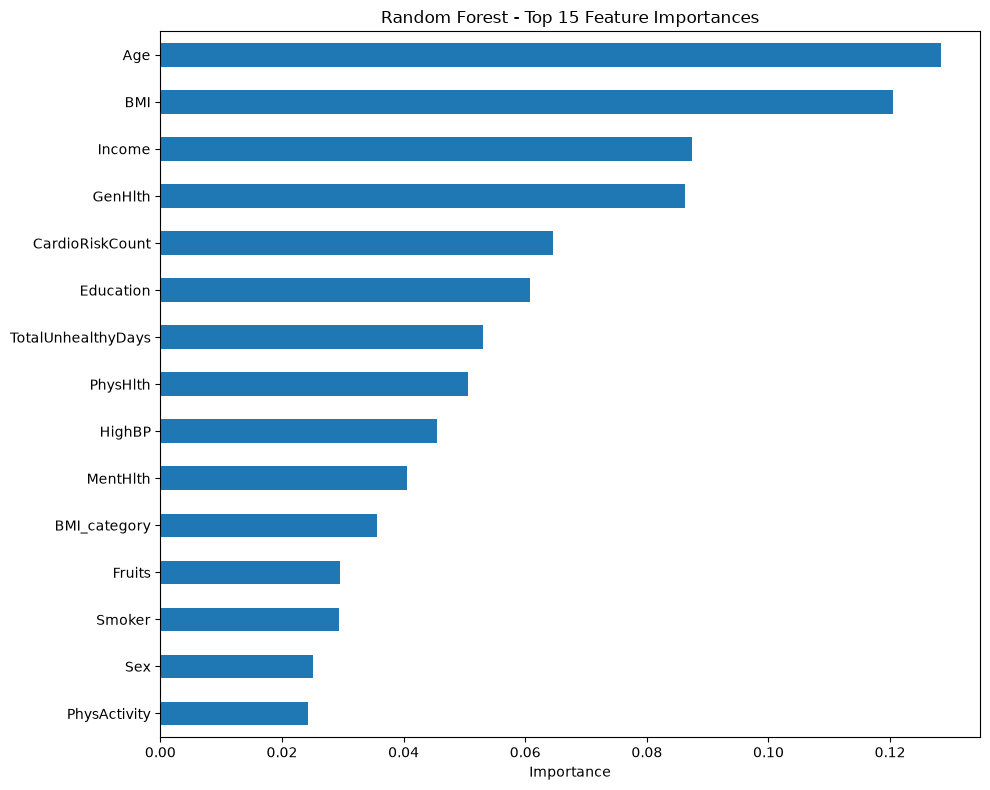

In [22]:
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
rf_importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/rf_feature_importance.png', dpi=150)
plt.show()

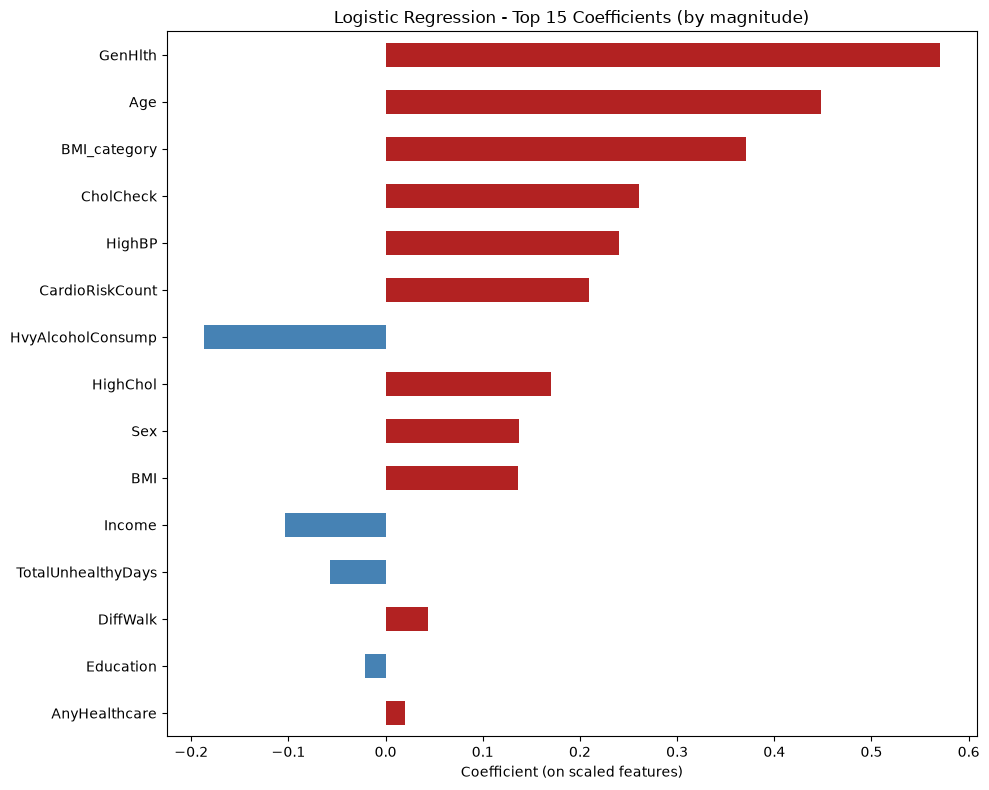

In [23]:
log_reg_coef = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['firebrick' if c > 0 else 'steelblue' for c in log_reg_coef.head(15)]
log_reg_coef.head(15).plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.title('Logistic Regression - Top 15 Coefficients (by magnitude)')
plt.xlabel('Coefficient (on scaled features)')
plt.tight_layout()
plt.savefig('outputs/logreg_coefficients.png', dpi=150)
plt.show()

**Feature importance summary:** GenHlth, Age, and BMI (or BMI_category) are the strongest predictors in both models. CardioRiskCount and TotalUnhealthyDays outrank their individual component features in Random Forest, validating the feature engineering. TotalUnhealthyDays shows a negative coefficient in logistic regression despite a positive raw correlation with diabetes — a multicollinearity effect from its overlap with MentHlth/PhysHlth, not a contradiction. Note: tree-based importance is biased toward high-cardinality features (Age, BMI, Income) over binary flags, so cross-checking against logistic regression coefficients is a useful sanity check rather than trusting either ranking alone.